# Pair Trading - Statistical Arbitrage

## Data Fetch

In [83]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [84]:
start_date = "2023-01-15"
end_date = '2026-03-12'
tick_wti = 'CL=F'
tick_brent = 'BZ=F'

In [85]:
df_wti = yf.download(tickers=tick_wti, start=start_date, end=end_date).interpolate(method='linear')
df_brent = yf.download(tickers=tick_brent, start=start_date, end=end_date).interpolate(method='linear')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [86]:
df_wti.head()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2023-01-17,80.180000,81.230003,78.529999,80.099998,312275
2023-01-18,79.480003,82.379997,78.940002,80.970001,92549
2023-01-19,80.330002,81.180000,78.129997,79.139999,58863
2023-01-20,81.309998,81.639999,79.690002,80.599998,300145
2023-01-23,81.620003,82.639999,81.050003,81.790001,297076


In [87]:
df_brent.head()

Price,Close,High,Low,Open,Volume
Ticker,BZ=F,BZ=F,BZ=F,BZ=F,BZ=F
Date,,,,,
2023-01-17,85.919998,86.820000,83.860001,85.440002,36658
2023-01-18,84.980003,87.839996,84.400002,86.720001,26461
2023-01-19,86.160004,86.849998,83.739998,84.589996,28822
2023-01-20,87.629997,87.769997,85.580002,86.360001,24374
2023-01-23,88.190002,89.099998,86.930000,87.809998,21194


Text(0.5, 1.0, 'WTI Crude Prices')

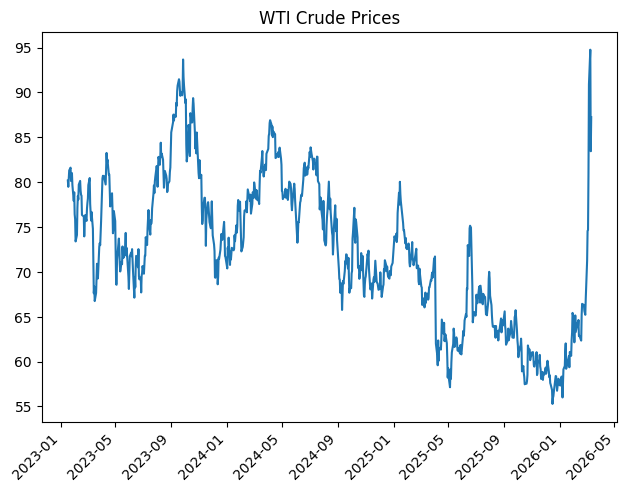

In [88]:
fig, ax = plt.subplots()
ax.plot(df_wti.Close)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.autofmt_xdate
ax.set_title('WTI Crude Prices')

Text(0.5, 1.0, 'Brent Crude Prices')

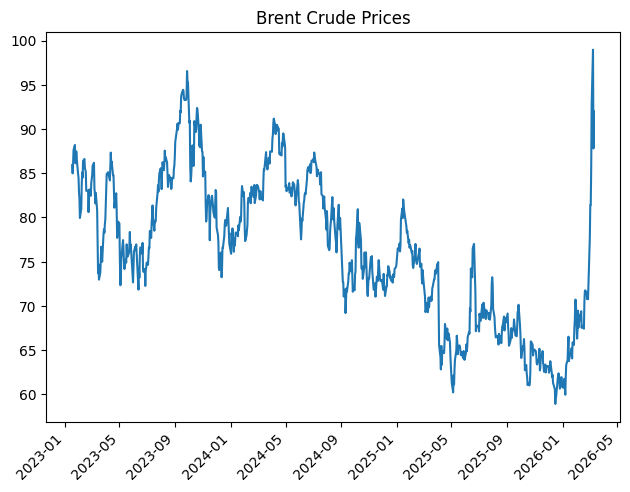

In [89]:
fig, ax = plt.subplots()
ax.plot(df_brent.Close)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.autofmt_xdate
ax.set_title('Brent Crude Prices')

In [90]:

for i in range(len(x_w)):
    if df_wti.index[i] != df_brent.index[i]:
        print(df_wti.index[i])
print(len(x_w), len(x_b))

2023-11-24 00:00:00
2023-11-27 00:00:00
2023-11-28 00:00:00
2023-11-29 00:00:00
2023-11-30 00:00:00
2023-12-01 00:00:00
2023-12-04 00:00:00
2023-12-05 00:00:00
2023-12-06 00:00:00
2023-12-07 00:00:00
2023-12-08 00:00:00
2023-12-11 00:00:00
2023-12-12 00:00:00
2023-12-13 00:00:00
2023-12-14 00:00:00
2023-12-15 00:00:00
2023-12-18 00:00:00
2023-12-19 00:00:00
2023-12-20 00:00:00
2023-12-21 00:00:00
2023-12-22 00:00:00
2023-12-26 00:00:00
2023-12-27 00:00:00
2023-12-28 00:00:00
2023-12-29 00:00:00
2024-01-02 00:00:00
2024-01-03 00:00:00
2024-01-04 00:00:00
2024-01-05 00:00:00
2024-01-08 00:00:00
2024-01-09 00:00:00
2024-01-10 00:00:00
2024-01-11 00:00:00
2024-01-12 00:00:00
2024-01-16 00:00:00
2024-01-17 00:00:00
2024-01-18 00:00:00
2024-01-19 00:00:00
2024-01-22 00:00:00
2024-01-23 00:00:00
2024-01-24 00:00:00
2024-01-25 00:00:00
2024-01-26 00:00:00
2024-01-29 00:00:00
2024-01-30 00:00:00
2024-01-31 00:00:00
2024-02-01 00:00:00
2024-02-02 00:00:00
2024-02-05 00:00:00
2024-02-06 00:00:00


In [91]:
wti_dates = set(df_wti.index)
brent_dates = set(df_brent.index)

only_in_wti = sorted(wti_dates - brent_dates)
only_in_brent = sorted(brent_dates - wti_dates)

print("Only in WTI:", only_in_wti[:20])
print("Count only in WTI:", len(only_in_wti))

print("Only in Brent:", only_in_brent[:20])
print("Count only in Brent:", len(only_in_brent))

Only in WTI: []
Count only in WTI: 0
Only in Brent: [Timestamp('2023-11-23 00:00:00')]
Count only in Brent: 1


In [114]:
from sklearn.model_selection import train_test_split
common_dates = df_wti.index.intersection(df_brent.index)

df_wti = df_wti.loc[common_dates].sort_index()
df_brent = df_brent.loc[common_dates].sort_index()

print(len(df_wti), len(df_brent))
print((df_wti.index == df_brent.index).all())
x_w = df_wti.Close
x_b = df_brent.Close
X_train_w, X_test_w, y_train_b, y_test_b = train_test_split(x_w, x_b, test_size=0.2, train_size=0.8, shuffle=False)



792 792
True


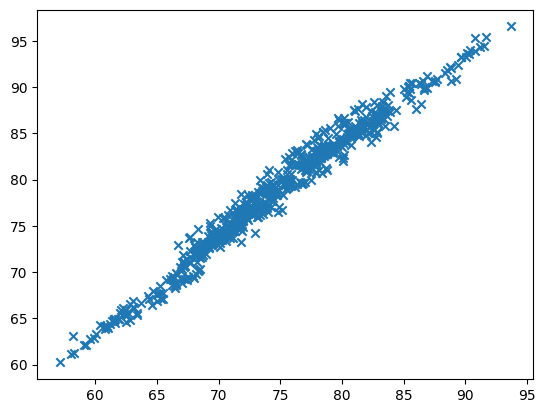

In [ ]:

from statsmodels.regression.linear_model import OLS



plt.scatter(X_train_w, y_train_b, marker='x')

In [123]:
from statsmodels.api import add_constant
X_train_w = add_constant(X_train_w) 
model = OLS(y_train_b, X_train_w)
model_fit = model.fit()
model_fit.summary()





<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   BZ=F   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                 2.553e+04
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:26:22   Log-Likelihood:                -955.82
No. Observations:                 633   AIC:                             1916.
Df Residuals:                     631   BIC:                             1925.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9294      0.482      4.000      0.000       0.982       2.877
CL=F           1.0281      0.006    159.781      0.000       1.015       1.041
==============================================================================
Omnibus:                       10.032   Durbin-Watson:                   0.136
Prob(Omnibus):                  0.007   Jarque-Bera (JB):               10.136
Skew:                           0.278   Prob(JB):                      0.00630
Kurtosis:                       3.274   Cond. No.                         829.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [124]:
params = model_fit.params
print(params)

const    1.929449
CL=F     1.028121
dtype: float64


In [125]:
from sklearn.metrics import mean_squared_error
X_test_w = add_constant(X_test_w)
y_pred_b = model_fit.predict(X_test_w)

mse = mean_squared_error(y_pred_b, y_test_b)
print(mse)




0.7011866147102284


ADF Statistic : -3.5154
P-value       : 0.0076
Critical (5%) : -2.8661
Cointegrated  : YES


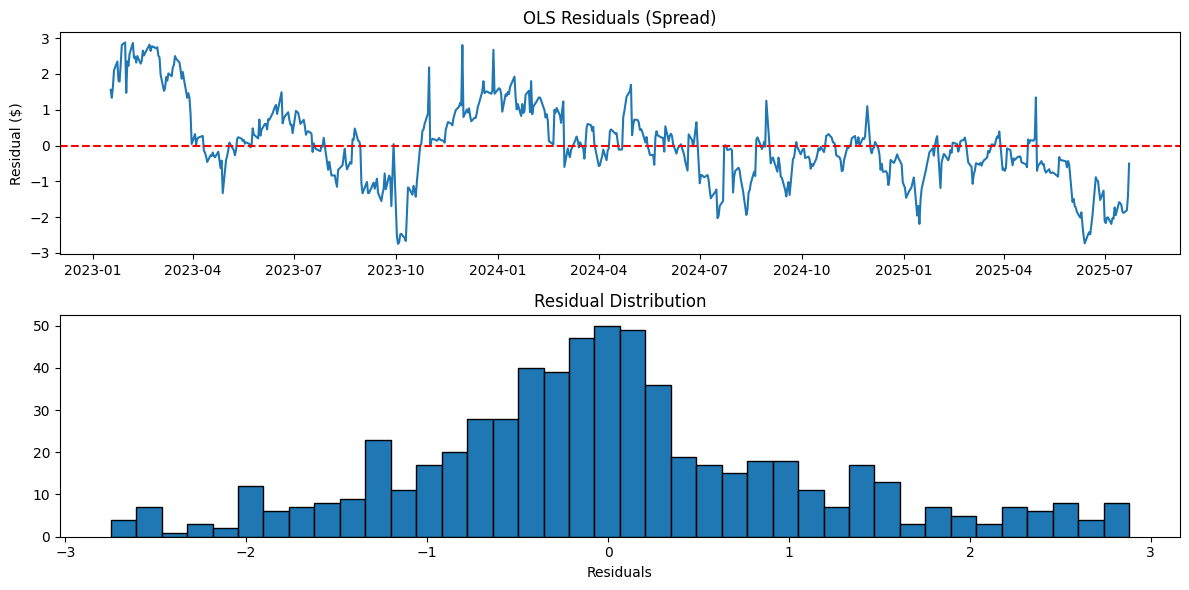

In [131]:
from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.stattools import adfuller

# Residuals from the training fit = the spread
residuals = model_fit.resid

# ADF test - null hypothesis is non-stationary (no mean reversion)
adf_result = adfuller(residuals)

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"P-value       : {adf_result[1]:.4f}")
print(f"Critical (5%) : {adf_result[4]['5%']:.4f}")
print(f"Cointegrated  : {'YES' if adf_result[1] < 0.05 else 'NO ✗'}")

# Also plot the residuals
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(residuals.index, residuals)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('OLS Residuals (Spread)')
axes[0].set_ylabel('Residual ($)')

axes[1].hist(residuals, bins=40, edgecolor='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

Given that the Ridge model is finding the $\bet$a$ parameter (correlation):

\begin{equation}
Y_\text{Brent} = \alpha + \beta X_\text{WTI} + \epsilon
\end{equation}

The spread is therefore:

\begin{equation}
\text{Spread} = Y_\text{Brent} - \alpha - \beta X_\text{WTI} 
\end{equation}

We can use the training data to evaluate what is a good threshold for which the z-score should be placed for reasonable profits

In [154]:
def z_score(arr, mu, std):
    return (arr - mu) / std

In [ ]:
from sklearn.linear_model import Ridge
from tqdm import tqdm

window = 60
beta_roll = pd.Series(index=X_train_w.index)
lambda_roll = pd.Series(index=X_train_w.index)
spread = residuals
lambdas = np.logspace(-4, 4)

for t in tqdm(range(window, len(X_train_w))):
    endog = X_train_w.iloc[t-window:t]
    exog = y_train_b.iloc[t-window:t]
    lambda_arr = np.array[]
    dict = {}
    n_folds = 3
    fold_test_len = int(window / (2*n_folds))
    for lam in lambdas:
        end = int(window / 2)
        splits = 0
        lambda_mse = np.array()
        while splits < n_folds:
            X_train_fold = endog.iloc[:end]
            y_train_fold = exog.iloc[:end]
            X_test_fold = endog.iloc[end:end+10]
            y_test_fold = exog.iloc[end:end+10]
            model = Ridge(lam)
            model_fit = model.fit(X_train_fold.values.reshape(-1,1), y_train_fold.values)
            beta = model_fit.coef_[0]
            alpha = model_fit.intercept_
            pars = [lam, beta, alpha]
            y_pred_fold = model_fit.predict(X_test_fold.values.reshape(-1,1))
            mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
            lambda_mse.append(mse_fold)
            end -= 10
            splits += 1
        
        dict[pars] = np.mean(mse_fold)
        lambda_best = None
    for key, val in dict:
        if lambda_best is None or val < lambda_best:
            lambda_best = val
            best_pars = key
    lambda_roll.iloc[t-window] = best_pars
        
    
    spread = exog - best_pars[2] - best_pars[1] * endog
    mu = spread.mean
    std = spread.std
    z = z_score(spread, mu, std)
    














100%|██████████| 573/573 [03:53<00:00,  2.46it/s]
